In [1]:
#load clean csv

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('posts_clean.csv')
df.head(5)

,post_id,title,score,comments,author,created,source_endpoint,subreddit,feed
0,1tf2ppl,¿Qué pasa después del breakout del Opening Ran...,0,5,mariodoblep,2026-05-16 19:11:00,new,unknown,new
1,1text64,Do I freak the fuck out and sell it all?,66,126,ZaraBloom418,2026-05-16 16:06:00,new,unknown,new
2,1texmf0,Is the SOFI hype warranted?,38,57,ZTB1313,2026-05-16 16:00:00,new,unknown,new
3,1texhaz,"So uhh, when do I get the forbidden phone (mar...",31,35,DeltaVx_,2026-05-16 15:54:00,new,unknown,new
4,1tex6av,"China, US agree to reduce tariffs on unspecifi...",581,119,Force_Hammer,2026-05-16 15:43:00,new,unknown,new


In [2]:
print(df.shape)
print(df.info())
print(df.describe())
print(df['source_endpoint'].value_counts())

(13218, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13218 entries, 0 to 13217
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          13218 non-null  object
 1   title            13218 non-null  object
 2   score            13218 non-null  int64 
 3   comments         13218 non-null  int64 
 4   author           13218 non-null  object
 5   created          13218 non-null  object
 6   source_endpoint  13218 non-null  object
 7   subreddit        13218 non-null  object
 8   feed             13218 non-null  object
dtypes: int64(2), object(7)
memory usage: 929.5+ KB
None
               score      comments
count   13218.000000  13218.000000
mean      782.143441    117.614919
std      3371.227438    264.352010
min         0.000000      0.000000
25%         3.000000      8.000000
50%        32.000000     33.000000
75%       284.000000    117.000000
max    126928.000000   5081.000000
source_endpoin

In [3]:
df["created"] = pd.to_datetime(df["created"], errors="coerce") # turning created column to datatime
df["created"]

0       2026-05-16 19:11:00
1       2026-05-16 16:06:00
2       2026-05-16 16:00:00
3       2026-05-16 15:54:00
4       2026-05-16 15:43:00
                ...        
13213   2025-10-07 15:59:00
13214   2025-09-11 15:55:00
13215   2025-07-25 10:12:00
13216   2025-06-24 02:49:00
13217   2025-12-11 13:34:00
Name: created, Length: 13218, dtype: datetime64[ns]

In [4]:
# ticker extraction

title = df["title"].fillna("").astype(str)

#ticker at the begining 
df["ticker"] = title.str.extract(r"^\$?([A-Z]{1,5})(?=[:\s\-\.\?!,)]|\b)", expand=False)

# # anywhere with break for dashes, dots, etc
df["ticker"] = df["ticker"].fillna(title.str.extract(r"\$([A-Z]{1,5})(?=[:\s\-\.\?!,)]|\b)",expand=False))

# ticker inside parenthessis
df["ticker"] = df["ticker"].fillna(title.str.extract(r"\(([A-Z]{1,5})\)",expand=False))

# ticker after key phrases
df["ticker"] = df["ticker"].fillna(title.str.extract(
r"\b(?:on|in|holding|long|buying|bought|sold|shorting|watching|trading|bullish on|bearish on|invested in)\s+\$?([A-Z]{1,5})(?=[:\s\-\.\?!,)]|\b)",expand=False))

# ticker before market phrases
df["ticker"] = df["ticker"].fillna(
title.str.extract(r"\b([A-Z]{1,5})\s+(?:calls|puts|options|shares|stock|leaps|earnings|squeeze|breakout|dip|run)\b",expand=False))

# ticker at the end
df["ticker"] = df["ticker"].fillna(title.str.extract(r"\b([A-Z]{1,5})[\.!\?]?$", expand=False))

df["ticker"] = df["ticker"].fillna(title.str.extract(r"\b([A-Z]{2,5})\b",expand=False)) # uppercase anywhere

df["ticker"] = df["ticker"].fillna(title.str.extract(r"\b([A-Za-z]{2,5})\s+(?:call|calls|put|puts|option|options|shares|stock)\b",expand=False).str.upper()) #catches targeted lowercase and turns them into upper case

In [5]:
df["ticker"].notna().sum()

6230

In [6]:
#Eliminating false positives

import numpy as np

bad_words = [
    "CEO", "CFO", "COO", "CTO", "CIO", "CMO", "VP", "FDA", "SEC", "FTC", "DOJ", "FBI", "IRS",
    "NYSE", "NASDAQ", "Nasdaq", "AMEX", "OTC",
    "IPO", "ETF", "ETFs", "EPS", "PE", "P/E", "PT", "ATH", "ATL", "ER", "PR", "DD", "TA",
    "YOLO", "FOMO", "FUD", "HODL", "MOON",
    "Q1", "Q2", "Q3", "Q4", "FY", "YTD", "EOD", "AH", "PM",
    "USA", "US", "UK", "EU", "CAD", "USD", "EUR", "JPY", "GBP",
    "AI", "GPU", "CPU", "EV", "SaaS", "API", "NFT", "VR", "AR",
    "AMA", "IMO", "TLDR", "LOL", "WTF", "LFG",
    "BUY", "SELL", "HOLD", "LONG", "SHORT",
    "CALL", "PUT", "CALLS", "PUTS", "IRA", "CPI", "ITM", "OTM", "IV", "DCF", "LEAPS",
    "ORB", "PDT", "MAY", "APRIL", "DRIP", "GPUS", "ES", "NOW", "OPEN", "CAR",
    "I", "A", "THE", "WHAT", "IS", "HOW", "S", "U", "PENNY", "FOR", "ONE", "MY", "WSJ", "AND",
    "WEEK", "DAILY", "SAYS", "VIX", "WSB"
]

df.loc[df["ticker"].isin(bad_words), "ticker"] = np.nan

In [7]:
percent_with_ticker = df['ticker'].notna().mean() *100
print(f'{percent_with_ticker:.2f}% of posts mentioned a ticker')

30.17% of posts mentioned a ticker


In [8]:
# checking the quality of the tickers

df["ticker"].value_counts().head(50) 

ticker
AMD      72
SPY      66
NVDA     61
MU       57
MSFT     55
INTC     45
SPX      45
SCHD     44
GOOGL    37
META     37
RKLB     30
QQQI     29
QQQ      27
GOOG     26
BURU     26
BYND     22
AMZN     22
UNH      20
ASTS     19
RDDT     19
POET     19
TSLA     19
SNDK     18
AAPL     16
MBOT     16
CVNA     16
IBKR     15
NBIS     15
ADBE     14
VOO      14
AIMN     13
MSTR     13
LULU     13
IBM      13
HOOD     13
HERB     12
RVPH     12
DFLI     12
CNBC     11
ATCH     11
TO       11
SCWO     11
NOMA     11
PLTR     11
BTC      11
NOT      11
ORCL     10
PSTV     10
KULR     10
HYSA     10
Name: count, dtype: int64

In [9]:
# Creating a list with top tickers 
top_5 = df["ticker"].value_counts().head(5).index.to_list() 
top_5 

# Turning into a dataframe
top_5_df = df[df["ticker"].isin(top_5)]
top_5_df

#saving for later use

top_5_df.to_parquet("top_5_df.parquet", index=False)

In [10]:
# Summary of the top 5 posts

top_5_summary = (top_5_df.groupby("ticker").agg(
    
        posts=("post_id", "count"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        total_score=("score", "sum"),
        avg_comments=("comments", "mean"),
        total_comments=("comments", "sum")
    )
    .sort_values("posts", ascending=False)
)

top_5_summary

,posts,avg_score,median_score,total_score,avg_comments,total_comments
ticker,,,,,,
AMD,72,1022.027778,61.5,73586,130.569444,9401
SPY,66,209.075758,17.0,13799,49.545455,3270
NVDA,61,1516.065574,78.0,92480,146.311475,8925
MU,57,258.035088,50.0,14708,79.087719,4508
MSFT,55,348.436364,132.0,19164,125.145455,6883


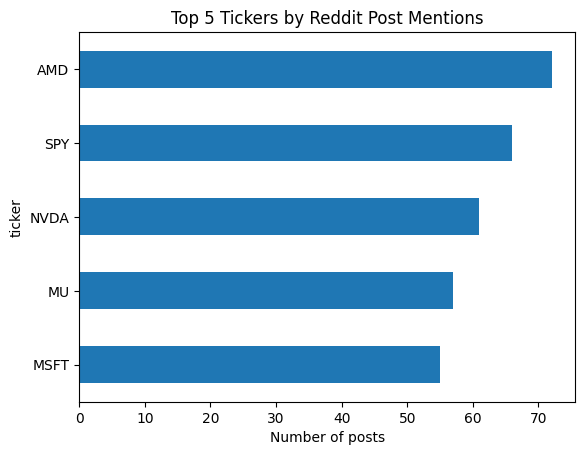

In [16]:
#plotting posts against ticker

top_5_summary["posts"].sort_values().plot(kind='barh')
plt.title("Top 5 Tickers by Reddit Post Mentions")
plt.xlabel("Number of posts")
plt.ylabel("ticker")
plt.savefig("charts/top_tickers_by_mentions.png", dpi=150, bbox_inches="tight")
plt.show()

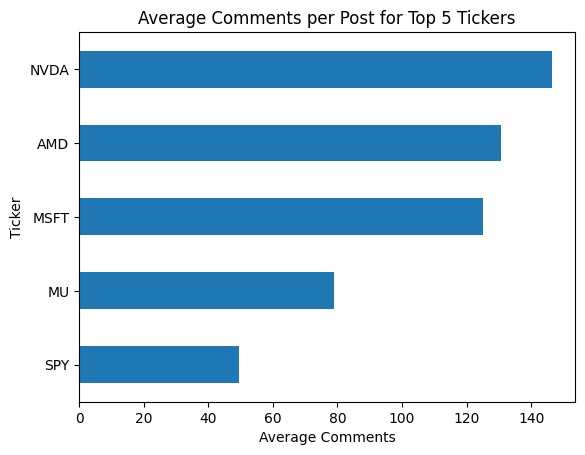

In [17]:
# plotting engagement

top_5_summary["avg_comments"].sort_values().plot(kind="barh")

plt.title("Average Comments per Post for Top 5 Tickers")
plt.xlabel("Average Comments")
plt.ylabel("Ticker")

plt.savefig("charts/avg_comments_per_post.png", dpi=150, bbox_inches="tight")
plt.show()

# Most Mentioned Tickers

The table below shows the five tickers that appeared most frequently in the Reddit finance dataset. These tickers represent the highest levels of retail attention based on post mentions.

| 1 | AMD | Most frequently mentioned ticker in the dataset |
| 2 | SPY | Broad market ETF with high discussion volume |
| 3 | NVDA | High-attention semiconductor/AI-related ticker |
| 4 | MU | Frequently discussed semiconductor ticker |
| 5 | MSFT | Large-cap tech ticker with strong Reddit attention |

In [13]:
# checking for viral posts

top_5_df.sort_values("score", ascending=False)[["ticker", "title", "score", "comments"]].head(10) 

,ticker,title,score,comments
3617,NVDA,Bought NVDA in 2022 because I liked gaming. 87...,16113,529
3620,NVDA,"Bought NVDA in 2022 because I liked gaming. 1,...",15527,511
499,AMD,AMD +$9.5M,13232,739
888,AMD,AMD. Another week. Another million. +$7.7M,12279,952
844,AMD,$350 → $52k God bless AMD,11208,666
3651,NVDA,What a crazy trap set for all $NVDA bulls,10337,1180
3657,NVDA,It would be NVDA,9853,286
3078,AMD,AMD. New high score: +$6M,7558,534
3737,NVDA,If you bought NVDA instead of a 1080ti at laun...,6085,370
3738,NVDA,NVDA at open today vs. 3 hours into trading,6071,174


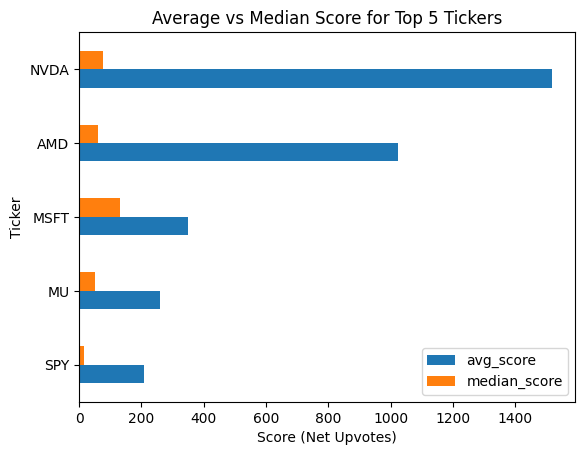

In [18]:
#plotting mean vs media

top_5_summary[["avg_score", "median_score"]].sort_values("avg_score", ascending=False)

top_5_summary[["avg_score", "median_score"]].sort_values("avg_score").plot(kind="barh")
plt.title("Average vs Median Score for Top 5 Tickers")
plt.xlabel("Score (Net Upvotes)")
plt.ylabel("Ticker")
plt.savefig("charts/avgvsmedian_score.png", dpi=150, bbox_inches="tight")
plt.show()

The significant difference between average score and median score shows that the engagement is skewed. With tickers like NVDA and AMD, for example, there is a higher average score compared to median score, meaning that some few well-performing posts have raised the mean. With this, median score becomes more meaningful in showing what an ordinary post would look like, while average score reflects the viral posts’ influence.

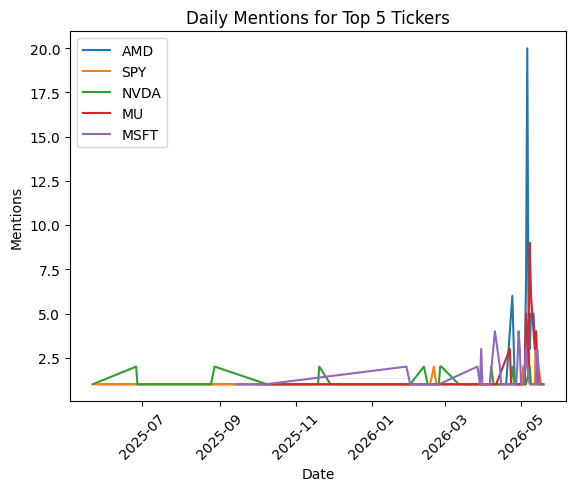

In [19]:
# post volume over time
ticker_daily = (
    top_5_df
    .groupby([top_5_df["created"].dt.date, "ticker"])
    .size()
    .reset_index(name="mentions")
)

for ticker in top_5:
    x = ticker_daily[ticker_daily["ticker"] == ticker]
    plt.plot(x["created"], x["mentions"], label=ticker)

plt.title("Daily Mentions for Top 5 Tickers")
plt.xlabel("Date")
plt.ylabel("Mentions")
plt.legend()
plt.xticks(rotation=45)
plt.savefig(f"charts/daily_mentions_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# Daily Mentions – Top 5 Tickers
Pretty quiet from mid-2025 all the way to April 2026, then AMD exploded to 20 mentions
in a single day with the others spiking right behind it. Likely earnings season getting
retail investors talking.